In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation


In [3]:
!pip install segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.8 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu1

In [4]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A

In [5]:
# Read Dataset
dataset_path = "/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m"

images = []
masks = []

for patient_folder in os.listdir(dataset_path):
    folder = os.path.join(dataset_path, patient_folder)

    if os.path.isdir(folder):
        for file in os.listdir(folder):
            if file.endswith(".tif") and "mask" not in file:
                img_path = os.path.join(folder, file)
                mask_path = img_path.replace(".tif", "_mask.tif")

                if os.path.exists(mask_path):
                    images.append(img_path)
                    masks.append(mask_path)

print(len(images))

3929


In [6]:
# split
train_imgs, temp_imgs, train_masks, temp_masks = train_test_split(
    images, masks, test_size=0.3, random_state=42
)

val_imgs, test_imgs, val_masks, test_masks = train_test_split(
    temp_imgs, temp_masks, test_size=0.5, random_state=42
)

In [7]:
#Dataset Class
class BrainDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (256, 256))
        image = image / 255.0

        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (256, 256))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=0)

        image = np.transpose(image, (2, 0, 1))

        return torch.tensor(image).float(), torch.tensor(mask).float()

In [8]:
# DataLoader
train_loader = DataLoader(BrainDataset(train_imgs, train_masks), batch_size=8, shuffle=True)
val_loader = DataLoader(BrainDataset(val_imgs, val_masks), batch_size=8)
test_loader = DataLoader(BrainDataset(test_imgs, test_masks), batch_size=8)

In [9]:
#Build Model with SMP
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [10]:
#Loss
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = torch.nn.BCEWithLogitsLoss()

In [11]:
def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

In [12]:
# Metrics
def iou_score(pred, target):
    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + 1e-6) / (union + 1e-6)

In [13]:
# Optimizer
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
# Training Loop
epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}")


Epoch 1: Loss=1.1854
Epoch 2: Loss=0.8556
Epoch 3: Loss=0.5838
Epoch 4: Loss=0.3225
Epoch 5: Loss=0.2391
Epoch 6: Loss=0.2172
Epoch 7: Loss=0.1784
Epoch 8: Loss=0.1696
Epoch 9: Loss=0.1763
Epoch 10: Loss=0.1450
Epoch 11: Loss=0.1338
Epoch 12: Loss=0.1469
Epoch 13: Loss=0.1474
Epoch 14: Loss=0.1299
Epoch 15: Loss=0.1162
Epoch 16: Loss=0.1242
Epoch 17: Loss=0.1637
Epoch 18: Loss=0.1426
Epoch 19: Loss=0.1169
Epoch 20: Loss=0.1108
Epoch 21: Loss=0.1001
Epoch 22: Loss=0.1045
Epoch 23: Loss=0.1185
Epoch 24: Loss=0.1096
Epoch 25: Loss=0.1278
Epoch 26: Loss=0.1009
Epoch 27: Loss=0.0987
Epoch 28: Loss=0.1038
Epoch 29: Loss=0.0987
Epoch 30: Loss=0.0909


In [15]:
# Validation Function
def validate(model, loader, device):
    model.eval()

    total_loss = 0
    total_iou = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            loss = loss_fn(preds, masks)

            total_loss += loss.item()
            total_iou += iou_score(preds, masks).item()

    return total_loss / len(loader), total_iou / len(loader)

In [16]:
#Dice Metric
def dice_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()

    intersection = (pred * target).sum()
    dice = (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    return dice

In [17]:
#Full Training Loop with Validation
epochs = 30
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)
    val_loss, val_iou = validate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val IoU: {val_iou:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print("Best model saved")

Epoch [1/30]
Train Loss: 0.1145
Val Loss: 0.1346
Val IoU: 0.7838
Best model saved
Epoch [2/30]
Train Loss: 0.1121
Val Loss: 0.1477
Val IoU: 0.7583
Epoch [3/30]
Train Loss: 0.1167
Val Loss: 0.1527
Val IoU: 0.7555
Epoch [4/30]
Train Loss: 0.0956
Val Loss: 0.1550
Val IoU: 0.7495
Epoch [5/30]
Train Loss: 0.1002
Val Loss: 0.1298
Val IoU: 0.7783
Best model saved
Epoch [6/30]
Train Loss: 0.1067
Val Loss: 0.1308
Val IoU: 0.7953
Epoch [7/30]
Train Loss: 0.0983
Val Loss: 0.1692
Val IoU: 0.7356
Epoch [8/30]
Train Loss: 0.1184
Val Loss: 0.1604
Val IoU: 0.7592
Epoch [9/30]
Train Loss: 0.0942
Val Loss: 0.1470
Val IoU: 0.7756
Epoch [10/30]
Train Loss: 0.0913
Val Loss: 0.2114
Val IoU: 0.7094
Epoch [11/30]
Train Loss: 0.1204
Val Loss: 0.1458
Val IoU: 0.7621
Epoch [12/30]
Train Loss: 0.0906
Val Loss: 0.1286
Val IoU: 0.7802
Best model saved
Epoch [13/30]
Train Loss: 0.0889
Val Loss: 0.1357
Val IoU: 0.7747
Epoch [14/30]
Train Loss: 0.0995
Val Loss: 0.1568
Val IoU: 0.7493
Epoch [15/30]
Train Loss: 0.1023
V

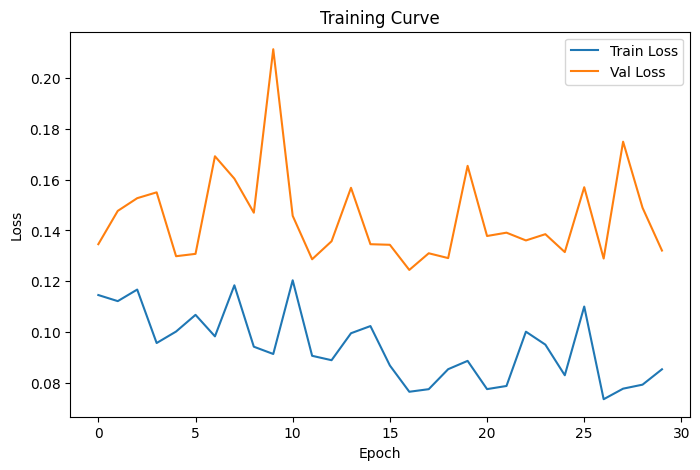

In [18]:
#Plot Training Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [19]:
#Load Best Model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [20]:
#Test Evaluation
test_iou = []
test_dice = []

with torch.no_grad():
    for images, masks in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)

        iou = iou_score(preds, masks)
        dice = dice_score(preds, masks)

        test_iou.append(iou.item())
        test_dice.append(dice.item())

print("Mean IoU:", np.mean(test_iou))
print("Mean Dice:", np.mean(test_dice))

Mean IoU: 0.7815704273853261
Mean Dice: 0.8538111924156457


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def visualize_prediction(model, loader, device, num_images=5):
    model.eval()

    # Get one batch
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        preds = model(images)
        preds = (torch.sigmoid(preds) > 0.5).float()

    batch_size = images.shape[0]

    # Select random indices
    random_idxs = random.sample(range(batch_size), min(num_images, batch_size))

    plt.figure(figsize=(15, num_images * 4))

    for i, idx in enumerate(random_idxs):
        image = images[idx].cpu().permute(1, 2, 0).numpy()
        mask = masks[idx][0].cpu().numpy()
        pred = preds[idx][0].cpu().numpy()

        # MRI Image
        plt.subplot(num_images, 3, i*3 + 1)
        plt.imshow(image)
        plt.title(f"MRI Image {i+1}")
        plt.axis("off")

        # Ground Truth
        plt.subplot(num_images, 3, i*3 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(num_images, 3, i*3 + 3)
        plt.imshow(pred, cmap='gray')
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

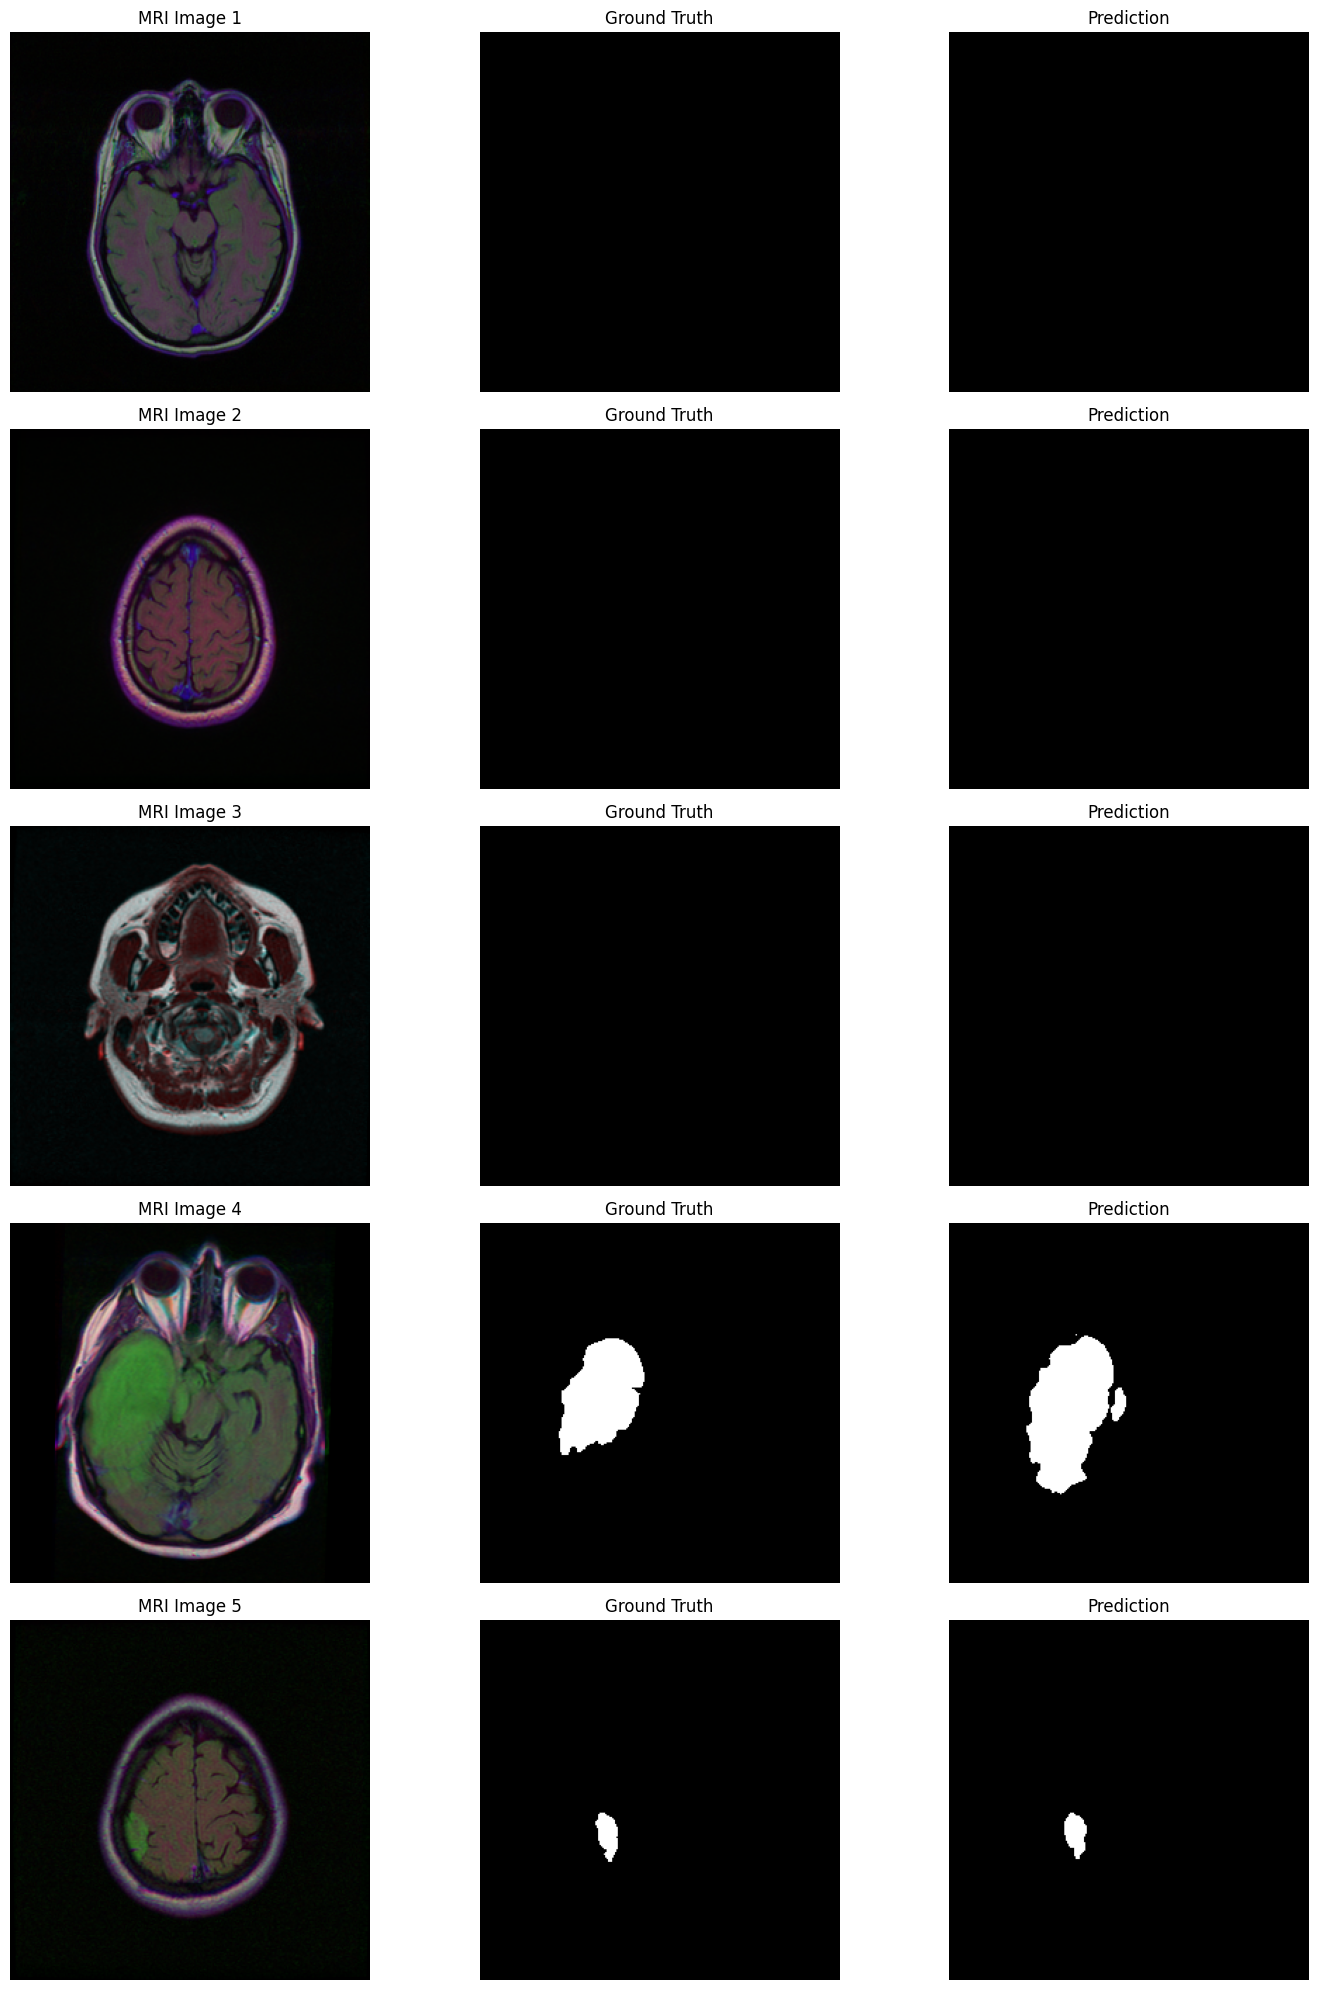

In [32]:
visualize_prediction(model, test_loader, device, num_images=5)